In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

In [4]:
X,y = make_regression( n_samples=100,
    n_features=1,
    n_informative=1,
    n_targets=1,
    effective_rank=None,
    tail_strength=0.5,
    noise=20,
    random_state=42)

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
lr = LinearRegression()

In [16]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
from sklearn.metrics import r2_score
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.8094169429876404

In [57]:
class GDRegressor:
    
    def __init__(self,learn_rate,epochs):
        #random value for mand b
        self.m = 233
        self.b = -210
        self.lr = learn_rate
        self.epochs = epochs

    def fit(self,X,y):

        for i in range(self.epochs):
            loss_slope_b = -2* np.sum(y- self.m * X.ravel() - self.b)
            loss_slope_m = -2* np.sum((y- self.m * X.ravel() - self.b)*X.ravel())

            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
            print(self.m,self.b)
            plt.scatter(self.epochs,self.b)

        print(self.m,self.b)

    def predict(self,X):
        return self.m * X.ravel() + self.b

    
        

-20.314091913765367 119.69936962800574
80.06945205441838 -62.16627845355043
30.1838042163455 30.38843981762861
55.40398379449033 -16.47727022064735
42.63911873386047 7.245655128197335
49.100373637536435 -4.762377134462319
45.82983214021421 1.3158206738811415
47.48530701527896 -1.7608270499525567
46.64734268349042 -0.2034968253327012
47.07150147497087 -0.991782532774237
46.85680178718974 -0.5927699491125293
46.965477964271216 -0.7947411892569793
46.910468515551905 -0.6925078675127551
46.93831306740925 -0.7442560870482825
46.92421877840642 -0.7180622964190696
46.92421877840642 -0.7180622964190696


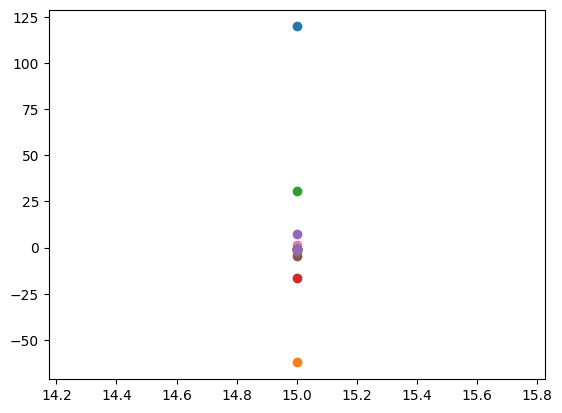

In [58]:
gd = GDRegressor(0.01,15)
gd.fit(X_train,y_train)

In [48]:
y_pred = gd.predict(X_test)
r2_score(y_test,y_pred)

0.8094169429876367